# Assignment 10

Laplace's equation is a second-order partial-differential equation that can be used to describe many phenomenon in science and engineering.  In two-dimensions it has the homogeneous form

$$
\frac{\partial^2 u(x,y)}{\partial x^2} + \frac{\partial^2 u(x,y)}{\partial y^2} = 0.
$$
    
Physically, this might represent a steady state heat conduction or pressure diffusivity problem.   You can use iterative procedure with a finite difference scheme to arrive at the steady-state solution.  If have implemented such a solver in the file [laplace.py](laplace.py).  To run this code we first import the `LaplaceSolver` class  

In [1]:
from laplace import LaplaceSolver

Now we can instantiate the class, creating the `solver` object and apply some boundary conditions.  In this case, we are applying a constant value $u(x,0) = u(x,1) = 10$.

In [2]:
solver = LaplaceSolver()
solver.set_boundary_condtion('top', lambda x,y: 10)
solver.set_boundary_condtion('bottom', lambda x,y: 10)

Now we can solve the problem.  Here we use the ipython magic command `%prun` to run the code in a profiler.

In [3]:
%prun solver.solve()

Solution converged in 288 iterations.
 

         325 function calls in 0.050 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      289    0.050    0.000    0.050    0.000 laplace.py:44(iterate)
        1    0.000    0.000    0.050    0.050 laplace.py:74(solve)
        3    0.000    0.000    0.000    0.000 iostream.py:195(schedule)
        2    0.000    0.000    0.000    0.000 iostream.py:366(write)
        1    0.000    0.000    0.050    0.050 {built-in method builtins.exec}
        3    0.000    0.000    0.000    0.000 threading.py:1062(_wait_for_tstate_lock)
        1    0.000    0.000    0.000    0.000 {built-in method builtins.print}
        3    0.000    0.000    0.000    0.000 threading.py:1104(is_alive)
        3    0.000    0.000    0.000    0.000 iostream.py:93(_event_pipe)
        2    0.000    0.000    0.000    0.000 iostream.py:300(_is_master_process)
        1    0.000    0.000    0.050    0.050 <string>:1(<module>)
        3    0.000    0.000    0.0

What the output of the profiler above shows is that the function `iterate` defined on line 44 of `laplace.py` is the most expensive part of the code.  Therefore, if we want to speed this code up, we should first focus our efforts on this function.

Just for completeness, I have plotted the solution below.

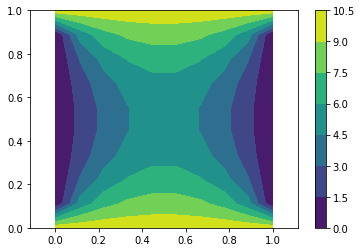

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(solver.xmin, solver.xmax + solver.dx * 0.5, solver.dx)
y = np.arange(solver.ymin, solver.ymax + solver.dy * 0.5, solver.dy)

X, Y = np.meshgrid(x, y)

plt.contourf(X, Y, solver.get_solution())
plt.axis('equal')
plt.colorbar();

I have rewritten the function `iterate` in C.  This implementation is in the file [iterate.c](iterate.c) and the function declaration is in the header file [iterate.h](iterate.h).  It's your task to write a SWIG interface file [iterate.i](iterate.i) that wraps the function `iterate` defined in [iterate.c](iterate.c). The Python module that SWIG generates can then be imported into [laplace.py](laplace.py) and the function `iterate` can be called as shown in `swig_solve()`.  Just uncomment out the import statement and return line.

Because the array `u` is a numpy array, I have included a [numpy.i](numpy.i) SWIG interface file, as well.  This can be used to assist in writing your [iterate.i](iterate.i) file.  You may want to look at the [numpy.i Documentation](https://docs.scipy.org/doc/numpy-1.13.0/reference/swig.interface-file.html) for additional help.  Once you've used used `swig` to generate the interface, you can use the following command to compile the iterface into a dynamic library

```bash
gcc -fPIC -std=c99 -shared iterate*.c -o _iterate.so -I$HOME/miniconda3/include/python3.6m -I$HOME/miniconda3/lib/python3.6/site-packages/numpy/core/include
```

In [6]:
solver.reset()
%timeit solver.solve(quiet=True)

147 µs ± 10.1 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [8]:
solver.reset()
%timeit solver.swig_solve(quiet=True)

1.84 µs ± 55.8 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
